# APEM Combined — Seeded Multi-Run Notebook

Adaptive Privacy Enhancement Mechanism in Differentially Private Federated Learning
Applied to IoT Botnet Detection


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Zone 1 — Definitions (run once)

In [ ]:
import math
import copy
import random
import os
import sys
import time
import contextlib
import io

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
)

print("Imports done.")


Imports done.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CONFIGURATION
# Edit SEEDS to control how many independent runs are performed.
# Each seed produces one complete training run (FL + DP-FL + APEM).
# ═══════════════════════════════════════════════════════════════

BASE_PATH    = "/content/drive/MyDrive/Thesis Dataset"
DISTRIBUTION = "nonIID"   # "IID" or "nonIID"
NUM_CLIENTS  = 10

# ── FL hyper-parameters — identical across all three models ──────────────────
NUM_ROUNDS   = 20
BATCH_SIZE   = 320
LR           = 0.0001
LOCAL_EPOCHS = 1
CLIP_NORM    = 0.5

# ── DP parameters ────────────────────────────────────────────────────────────
NOISE_MULTIPLIER = 10
MAX_EPSILON      = 32.0
DELTA            = 1e-5

# ── APEM-specific parameters ─────────────────────────────────────────────────
AAL       = 0.05
NA        = 0.005
ND        = 0.00375
PAI       = 100_000
MAX_NOISE = 2.0
S         = 2
U         = 2

# ── Attack parameters ─────────────────────────────────────────────────────────
ATTACK_BATCH_SIZE = 32   # Samples per intercepted client update
ATTACK_N_TRIALS   = 5    # Random reference gradient trials per client

Name = "Vivs"

# ── Seeds — add or remove seeds to control number of runs ────────────────────
# Each seed = one full independent training run of all three models.
# Results are saved per seed and combined at the end.
SEEDS = [27]

# ── Root results folder ───────────────────────────────────────────────────────
RESULTS_ROOT = f"/content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10"
os.makedirs(RESULTS_ROOT, exist_ok=True)

# Combined output folder — created after all seeds finish
COMBINED_FOLDER = os.path.join(RESULTS_ROOT, f"PAI_{PAI}_{DISTRIBUTION}_27")
os.makedirs(COMBINED_FOLDER, exist_ok=True)

print(f"Distribution  : {DISTRIBUTION}")
print(f"Seeds         : {SEEDS}")
print(f"Total runs    : {len(SEEDS)}")
print(f"Results root  : {RESULTS_ROOT}")
print(f"Combined out  : {COMBINED_FOLDER}")


Distribution  : nonIID
Seeds         : [27]
Total runs    : 1
Results root  : /content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10
Combined out  : /content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10/PAI_100000_nonIID_27


In [ ]:
class ClientDataset(Dataset):
    def __init__(self, df):
        for col in df.columns:
            if col != "label_encoded":
                df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.fillna(0)
        self.X = torch.tensor(df.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
        self.y = torch.tensor(df["label_encoded"].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("Classes defined.")


Classes defined.


In [ ]:
def set_seed(seed):
    """
    Set all random seeds for full reproducibility within a run.
    Controls: Python random, NumPy, PyTorch (CPU).
    Each seed in SEEDS produces a genuinely independent run because
    different seeds draw different random noise samples and shuffle orders.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    print(f"  Seed set to {seed}")

print("set_seed defined.")


set_seed defined.


In [ ]:
def load_client_data(num_clients, distribution, base_path):
    client_dfs = []
    for i in range(1, num_clients + 1):
        path = f"{base_path}/client{i}-{distribution}.csv"
        client_dfs.append(pd.read_csv(path))
    print(f"  Loaded {num_clients} client datasets ({distribution}).")
    return client_dfs


def load_test_data(path):
    df = pd.read_csv(path)
    for col in df.columns:
        if col != "label_encoded":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.fillna(0).dropna(subset=["label_encoded"])


def make_dataloader(df, batch_size):
    return DataLoader(ClientDataset(df), batch_size=batch_size, shuffle=True)

print("Data loading functions defined.")


Data loading functions defined.


In [ ]:
def init_global_model(client_dfs):
    """Build global MLP and class-weighted loss from combined client data."""
    input_dim  = client_dfs[0].drop(["label", "label_encoded"], axis=1).shape[1]
    all_labels = pd.concat(client_dfs)["label_encoded"]
    pos        = (all_labels == 1).sum()
    neg        = (all_labels == 0).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
    model      = MLP(input_dim)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    return model, loss_fn, input_dim


def compute_model_update(client_model, global_model):
    """Return weight difference between client and global model."""
    return {
        key: client_model.state_dict()[key] - global_model.state_dict()[key]
        for key in global_model.state_dict()
    }


def federated_average(global_model, client_updates):
    """Aggregate client updates into global model via unweighted FedAvg."""
    global_dict = global_model.state_dict()
    for key in global_dict:
        stacked = torch.stack([upd[key] for upd in client_updates], dim=0)
        global_dict[key] += stacked.mean(0)
    global_model.load_state_dict(global_dict)
    return global_model


def clip_update(update, clip_norm):
    """Clip model update to maximum L2 norm (C)."""
    total_norm  = torch.sqrt(sum(torch.norm(v) ** 2 for v in update.values()))
    clip_factor = min(1.0, clip_norm / (total_norm + 1e-6))
    return {key: v * clip_factor for key, v in update.items()}


def train_client(client_df, global_model, loss_fn, input_dim,
                 lr, batch_size, local_epochs, clip_norm):
    """
    Train a local copy of the global model on one client's data.
    Returns (trained_model, total_rows_processed, final_batch_loss).
    """
    loader       = make_dataloader(client_df, batch_size)
    client_model = MLP(input_dim)
    client_model.load_state_dict(global_model.state_dict())
    optimizer    = optim.Adam(client_model.parameters(), lr=lr)
    rows_processed = 0
    loss           = torch.tensor(0.0)
    for _ in range(local_epochs):
        for X, y in loader:
            rows_processed += len(X)
            optimizer.zero_grad()
            loss = loss_fn(client_model(X), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(client_model.parameters(), clip_norm)
            optimizer.step()
    return client_model, rows_processed, loss.item()


def evaluate_global_model(model, client_dfs):
    """Evaluate global model accuracy on combined client training data."""
    df_full = pd.concat(client_dfs).reset_index(drop=True)
    for col in df_full.columns:
        if col != "label_encoded":
            df_full[col] = pd.to_numeric(df_full[col], errors="coerce")
    df_full = df_full.fillna(0)
    X = torch.tensor(df_full.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
    y = torch.tensor(df_full["label_encoded"].values, dtype=torch.float32).unsqueeze(1)
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X)) > 0.5).float()
    return accuracy_score(y.numpy(), preds.numpy())


def evaluate_on_test_set(model, df_test):
    """Run full metric evaluation on the held-out test set."""
    X = torch.tensor(df_test.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
    y = torch.tensor(df_test["label_encoded"].values, dtype=torch.float32).unsqueeze(1)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X))
        preds = (probs > 0.5).float()
    y_true   = y.cpu().numpy()
    y_pred   = preds.cpu().numpy()
    probs_np = probs.cpu().numpy()
    cm       = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred),
        "roc_auc":   roc_auc_score(y_true, probs_np),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }


def avg_epsilon(epsilons):
    """Mean epsilon across active (non-zero) clients."""
    active = [e for e in epsilons if e > 0]
    return sum(active) / len(active) if active else 0.0


def compute_privacy_utility_score(epsilons, accuracy):
    """
    Privacy-Utility Score = accuracy / avg_epsilon.
    Higher = more accuracy per unit of privacy budget spent.
    N/A for FL (no epsilon).
    """
    avg_eps = avg_epsilon(epsilons)
    pu      = accuracy / avg_eps if avg_eps > 0 else 0.0
    return {"avg_epsilon": avg_eps, "accuracy": accuracy, "pu_score": pu}

print("Core FL functions defined.")


Core FL functions defined.


In [ ]:
def add_gaussian_noise(update, clip_norm, noise_multiplier):
    """Add calibrated Gaussian noise (σ · C) to a clipped model update."""
    return {
        key: v + torch.normal(mean=0.0, std=noise_multiplier * clip_norm, size=v.shape)
        for key, v in update.items()
    }


def compute_rdp(noise_multiplier, sample_rate, steps, orders):
    """
    Compute per-order Rényi DP for the subsampled Gaussian mechanism.
    This is a conservative approximation: ε_a = (a / 2σ²) × steps × q
    where q is the sampling rate and steps is the number of optimization steps.
    """
    if noise_multiplier == 0:
        return np.full(len(orders), float("inf"))
    return (orders / (2 * noise_multiplier ** 2)) * steps * sample_rate


def rdp_to_epsilon(orders, rdp, delta):
    """Convert accumulated RDP to the tightest (ε, δ)-DP guarantee."""
    epsilons = rdp - (np.log(delta) / (orders - 1))
    idx      = np.argmin(epsilons)
    return epsilons[idx], orders[idx]

print("DP utilities defined.")


DP utilities defined.


In [ ]:
def adjust_noise_for_pai(noise, rows_cumulative, pai, na, max_noise, is_unstable):
    """
    Increase client noise when processed rows cross PAI thresholds.
    If the client is unstable, the NA increment is halved.
    Returns (updated_noise, remaining_cumulative_rows).
    """
    increments = rows_cumulative // pai
    if increments == 0:
        return noise, rows_cumulative
    effective_na   = na / 2 if is_unstable else na
    noise          = min(noise + increments * effective_na, max_noise)
    rows_remaining = rows_cumulative - increments * pai
    return noise, rows_remaining


def update_stability_counters(stable_rounds, unstable_rounds, prev_sigma, current_sigma):
    """
    Increment the correct stability counter based on σ change direction.
    Only a strict σ increase counts as an instability event.
    A σ decrease (from stability reward or AAL) resets the unstable counter
    and increments the stable counter instead.
    Returns (stable_rounds, unstable_rounds).
    """
    if current_sigma > prev_sigma + 1e-6:   # noise increased → instability event
        return 0, unstable_rounds + 1
    return stable_rounds + 1, 0             # noise unchanged or decreased → stable


def adjust_noise_for_stability(noise, stable_rounds, unstable_rounds, nd, max_noise, S):
    """
    Decrease noise and reset counters once a client has been stable for S rounds.
    Returns (updated_noise, stable_rounds, unstable_rounds).
    """
    if stable_rounds < S:
        return noise, stable_rounds, unstable_rounds
    noise = min(max(0.01, noise - nd), max_noise)
    return noise, 0, 0


def apply_aal_noise_reduction(client_noise, nd, max_noise, num_clients):
    """
    Reduce every client's noise when global accuracy drops by more than AAL.
    Also resets all stability counters.
    Returns (client_noise, client_stable_rounds, client_unstable_rounds).
    """
    new_noise = [min(max(0.01, n - nd), max_noise) for n in client_noise]
    return new_noise, [0] * num_clients, [0] * num_clients

print("APEM functions defined.")


APEM functions defined.


In [ ]:
# Global timing accumulator — reset before each model training run
timing_log = {
    'train':    [],   # seconds per client per round (local training)
    'update':   [],   # compute_model_update + clip_update
    'noise':    [],   # add_gaussian_noise only
    'overhead': [],   # APEM-specific logic (PAI, AAL, stability checks)
}

def reset_timing():
    """Clear all timing accumulators before a new model training run."""
    for k in timing_log:
        timing_log[k] = []

def get_timing_totals():
    """Return total seconds per component and grand total."""
    totals = {}
    grand  = 0.0
    for key, values in timing_log.items():
        t = float(np.sum(values)) if values else 0.0
        totals[key] = t
        grand += t
    totals['total'] = grand
    return totals

def save_timing_csv(label, model_tag, save_path):
    """Save timing breakdown to CSV in the per-seed folder."""
    _path = os.path.join(save_path, f"timing_{model_tag}.csv")
    rows  = []
    grand = 0.0
    for key, values in timing_log.items():
        if values:
            arr = np.array(values)
            rows.append({
                "model":     label,
                "component": key,
                "mean_s":    round(arr.mean(), 6),
                "std_s":     round(arr.std(), 6),
                "total_s":   round(arr.sum(), 6),
                "n_obs":     len(values),
            })
            grand += arr.sum()
        else:
            rows.append({
                "model":     label,
                "component": key,
                "mean_s":    None, "std_s": None,
                "total_s":   None, "n_obs": 0,
            })
    rows.append({
        "model": label, "component": "TOTAL",
        "mean_s": None, "std_s": None,
        "total_s": round(grand, 6), "n_obs": None,
    })
    pd.DataFrame(rows).to_csv(_path, index=False)

print("Timing helpers defined.")


Timing helpers defined.


In [ ]:
def run_fl(client_dfs, global_model, loss_fn, input_dim,
           num_rounds, batch_size, lr, local_epochs, clip_norm):
    """
    Run standard (non-private) federated learning.
    Updates are clipped but no noise is added. No privacy accounting.
    Returns (trained_global_model, acc_history).
    """
    acc_history = []
    for round_num in range(num_rounds):
        print(f"\n{'='*50}\nRound {round_num + 1} / {num_rounds}\n{'='*50}")
        client_updates = []
        for i, client_df in enumerate(client_dfs):
            _t0 = time.perf_counter()
            client_model, rows_this_round, final_loss = train_client(
                client_df, global_model, loss_fn, input_dim,
                lr, batch_size, local_epochs, clip_norm,
            )
            timing_log['train'].append(time.perf_counter() - _t0)
            _t0 = time.perf_counter()
            update = compute_model_update(client_model, global_model)
            update = clip_update(update, clip_norm)
            timing_log['update'].append(time.perf_counter() - _t0)
            client_updates.append(update)
            print(f"  [C{i+1}] loss={final_loss:.4f} | rows={rows_this_round}")
        global_model = federated_average(global_model, client_updates)
        global_acc   = evaluate_global_model(global_model, client_dfs)
        acc_history.append(global_acc)
        print(f"\n  Global accuracy: {global_acc:.4f}")
        print("="*42)
    return global_model, acc_history


def run_dp_fl(client_dfs, global_model, loss_fn, input_dim,
              num_rounds, batch_size, lr, local_epochs,
              clip_norm, noise_multiplier, max_epsilon, delta):
    """
    Run Static DP-FL. Fixed noise multiplier throughout all rounds.
    Clients exceeding max_epsilon stop contributing.
    Returns (trained_global_model, client_epsilons, acc_history).
    """
    num_clients     = len(client_dfs)
    orders          = np.arange(2, 64)
    client_rdp      = [np.zeros(len(orders), dtype=float) for _ in range(num_clients)]
    client_epsilons = [0.0] * num_clients
    acc_history     = []

    for round_num in range(num_rounds):
        print(f"\n{'='*50}\nRound {round_num + 1} / {num_rounds}\n{'='*50}")
        client_updates = []
        for i, client_df in enumerate(client_dfs):
            if client_epsilons[i] > max_epsilon:
                print(f"  [C{i+1}] Skipped — ε={client_epsilons[i]:.4f} exceeds budget.")
                continue
            _t0 = time.perf_counter()
            client_model, rows_this_round, final_loss = train_client(
                client_df, global_model, loss_fn, input_dim,
                lr, batch_size, local_epochs, clip_norm,
            )
            timing_log['train'].append(time.perf_counter() - _t0)
            _t0 = time.perf_counter()
            update = compute_model_update(client_model, global_model)
            update = clip_update(update, clip_norm)
            timing_log['update'].append(time.perf_counter() - _t0)
            _t0 = time.perf_counter()
            update = add_gaussian_noise(update, clip_norm, noise_multiplier)
            timing_log['noise'].append(time.perf_counter() - _t0)
            dataset_size   = len(ClientDataset(client_df))
            sample_rate    = batch_size / dataset_size
            steps          = math.ceil(dataset_size / batch_size) * local_epochs
            rdp_round      = compute_rdp(noise_multiplier, sample_rate, steps, orders)
            client_rdp[i] += rdp_round
            eps, _         = rdp_to_epsilon(orders, client_rdp[i], delta)
            client_epsilons[i] = eps
            print(f"  [C{i+1}] loss={final_loss:.4f} | rows={rows_this_round} | ε={eps:.4f} | σ={noise_multiplier:.4f}")
            if eps > max_epsilon:
                print(f"  [C{i+1}] Budget exceeded — update discarded.")
                continue
            client_updates.append(update)
        if not client_updates:
            print("No client updates. Stopping early.")
            break
        global_model = federated_average(global_model, client_updates)
        global_acc   = evaluate_global_model(global_model, client_dfs)
        acc_history.append(global_acc)
        print(f"\n  Global accuracy: {global_acc:.4f}")
        print("="*42)
    return global_model, client_epsilons, acc_history


def run_apem(client_dfs, global_model, loss_fn, input_dim,
             num_rounds, batch_size, lr, local_epochs, clip_norm,
             noise_multiplier, max_epsilon, delta,
             aal, na, nd, pai, max_noise, S, U):
    """
    Run APEM. Adaptive noise per client based on stability, PAI, and AAL.

    Noise adjustment rules
    ----------------------
    Stability : Check BEFORE PAI. Only a strict σ increase = instability.
                Decrease noise by ND after S consecutive stable rounds.
                Save prev_sigma AFTER stability adjusts noise.
    PAI       : Increase noise by NA (or NA/2 if unstable) per PAI crossing.
    AAL       : Decrease ALL client noise by ND when global accuracy drops >= AAL.
                Sync prev_sigma after AAL to avoid miscounting next round.
    Budget    : Clients exceeding max_epsilon stop contributing.

    Returns (trained_global_model, client_epsilons, acc_history, final_client_noise).
    final_client_noise is the per-client σ at the end of training —
    used by the attack section to simulate APEM's actual adaptive noise levels.
    """
    num_clients       = len(client_dfs)
    orders            = np.arange(2, 64)
    client_rdp        = [np.zeros(len(orders), dtype=float) for _ in range(num_clients)]
    client_epsilons   = [0.0] * num_clients
    client_noise      = [noise_multiplier] * num_clients
    client_rows       = [0]   * num_clients
    client_stable     = [0]   * num_clients
    client_unstable   = [0]   * num_clients
    client_prev_sigma = [noise_multiplier] * num_clients
    prev_global_acc   = None
    acc_history       = []

    for round_num in range(num_rounds):
        print(f"\n{'='*50}\nRound {round_num + 1} / {num_rounds}\n{'='*50}")
        client_updates = []
        for i, client_df in enumerate(client_dfs):
            # (1) Budget check
            if client_epsilons[i] > max_epsilon:
                print(f"  [C{i+1}] Skipped — ε={client_epsilons[i]:.4f} exceeds budget.")
                continue
            # (2) Local training
            _t0 = time.perf_counter()
            client_model, rows_this_round, final_loss = train_client(
                client_df, global_model, loss_fn, input_dim,
                lr, batch_size, local_epochs, clip_norm,
            )
            timing_log['train'].append(time.perf_counter() - _t0)
            client_rows[i] += rows_this_round
            _t0 = time.perf_counter()
            # (3) Stability check — BEFORE PAI so PAI does not poison the signal
            client_stable[i], client_unstable[i] = update_stability_counters(
                client_stable[i], client_unstable[i], client_prev_sigma[i], client_noise[i],
            )
            client_noise[i], client_stable[i], client_unstable[i] = adjust_noise_for_stability(
                client_noise[i], client_stable[i], client_unstable[i], nd, max_noise, S,
            )
            # Save AFTER stability adjusts noise — correct next-round comparison
            client_prev_sigma[i] = client_noise[i]
            # (4) PAI adjustment
            is_unstable = client_unstable[i] >= U
            client_noise[i], client_rows[i] = adjust_noise_for_pai(
                client_noise[i], client_rows[i], pai, na, max_noise, is_unstable,
            )
            timing_log['overhead'].append(time.perf_counter() - _t0)
            # (5) Build DP update with final adaptive noise
            _t0 = time.perf_counter()
            update = compute_model_update(client_model, global_model)
            update = clip_update(update, clip_norm)
            timing_log['update'].append(time.perf_counter() - _t0)
            _t0 = time.perf_counter()
            update = add_gaussian_noise(update, clip_norm, client_noise[i])
            timing_log['noise'].append(time.perf_counter() - _t0)
            # (6) Privacy accounting
            dataset_size  = len(ClientDataset(client_df))
            sample_rate   = batch_size / dataset_size
            steps         = math.ceil(dataset_size / batch_size) * local_epochs
            rdp_round     = compute_rdp(client_noise[i], sample_rate, steps, orders)
            client_rdp[i] += rdp_round
            eps, _        = rdp_to_epsilon(orders, client_rdp[i], delta)
            client_epsilons[i] = eps
            print(
                f"  [C{i+1}] loss={final_loss:.4f} | rows={rows_this_round} | "
                f"ε={eps:.4f} | σ={client_noise[i]:.4f} | "
                f"stable={client_stable[i]} | unstable={client_unstable[i]}"
            )
            if eps > max_epsilon:
                print(f"  [C{i+1}] Budget exceeded — update discarded.")
                continue
            client_updates.append(update)
        if not client_updates:
            print("No client updates. Stopping early.")
            break
        global_model = federated_average(global_model, client_updates)
        global_acc   = evaluate_global_model(global_model, client_dfs)
        acc_history.append(global_acc)
        print(f"\n  Global accuracy: {global_acc:.4f}")
        # (7) AAL check
        if prev_global_acc is not None and (prev_global_acc - global_acc) >= aal:
            print(f"  [AAL] Accuracy dropped >= {aal}. Reducing all client noise by ND={nd}.")
            client_noise, client_stable, client_unstable = apply_aal_noise_reduction(
                client_noise, nd, max_noise, num_clients,
            )
            # Sync prev_sigma so next round stability check reflects AAL-reduced σ
            client_prev_sigma = list(client_noise)
        prev_global_acc = global_acc
        print("="*42)

    # Return final per-client noise — used by attack section for honest APEM comparison
    return global_model, client_epsilons, acc_history, list(client_noise)

print("Training loops defined.")


Training loops defined.


In [ ]:
# GRADIENT INVERSION ATTACK — GRADIENT COSINE SIMILARITY

def capture_client_gradient(client_model, loss_fn, client_df, batch_size):
    """
    Compute the gradient embedded in a client's intercepted model update.
    The gradient direction is what an attacker tries to exploit.
    A clean gradient (no DP) has a strong consistent direction.
    A noisy gradient (DP applied) has a corrupted, unpredictable direction.
    """
    dataset = ClientDataset(client_df)
    indices = list(range(min(batch_size, len(dataset))))
    X_batch = torch.stack([dataset[i][0] for i in indices])
    y_batch = torch.stack([dataset[i][1] for i in indices])
    client_model.eval()
    client_model.zero_grad()
    pred = client_model(X_batch)
    loss = loss_fn(pred, y_batch)
    loss.backward()
    grad_flat = torch.cat([
        p.grad.clone().detach().flatten()
        for p in client_model.parameters()
        if p.grad is not None
    ])
    client_model.zero_grad()
    return grad_flat


def compute_reference_gradient(client_model, loss_fn, input_dim, batch_size):
    """
    Compute a gradient from random dummy data on the same model.
    This is the attacker's reference — no relationship to real training data.
    High cosine similarity with real gradient = update carries exploitable signal.
    Low cosine similarity = DP noise has destroyed the signal.
    """
    dummy_X = torch.randn(batch_size, input_dim)
    dummy_y = torch.zeros(batch_size, 1)
    client_model.eval()
    client_model.zero_grad()
    pred = client_model(dummy_X)
    loss = loss_fn(pred, dummy_y)
    loss.backward()
    ref_grad_flat = torch.cat([
        p.grad.clone().detach().flatten()
        for p in client_model.parameters()
        if p.grad is not None
    ])
    client_model.zero_grad()
    return ref_grad_flat


def run_attack_on_trained_models(
        client_dfs, fl_model, dpfl_model, apem_model,
        loss_fn, input_dim, apem_final_noise,
        attack_batch_size=32, n_dummy_trials=5):
    """
    Run gradient cosine similarity attack on all 10 clients for all 3 models.

    Uses the actual trained model states from this seed's training run.
    For APEM, uses the actual per-client final noise values (apem_final_noise)
    rather than the initial σ — making the comparison genuinely reflective
    of APEM's adaptive behavior across the full training run.

    Parameters
    ----------
    fl_model          : Trained FL model (this seed's run).
    dpfl_model        : Trained Static DP-FL model (this seed's run).
    apem_model        : Trained APEM model (this seed's run).
    loss_fn           : Loss function matching FL training.
    input_dim         : Number of input features.
    apem_final_noise  : List of per-client final σ values from APEM training.
                        These are the real adaptive noise levels — not initial σ.
    attack_batch_size : Samples per intercepted batch.
    n_dummy_trials    : Random reference gradient trials per client (mean reported).

    Returns
    -------
    results : Dict with per-client cosine similarities for FL, DPFL, APEM.
    means   : Dict with overall mean cosine similarity per model.
    """
    def _attack_one_model(trained_model, noise_sigmas, label):
        """
        noise_sigmas: list of per-client σ values.
                      None means no noise (FL).
        """
        per_client = []
        client_results = {}
        for client_idx, client_df in enumerate(client_dfs):
            client_label = f"C{client_idx + 1}"
            # Train one local round from the trained model's weights
            # This simulates intercepting the update at that model's state
            client_model, _, _ = train_client(
                client_df, trained_model, loss_fn,
                input_dim, LR, attack_batch_size, LOCAL_EPOCHS, CLIP_NORM,
            )
            # Apply DP noise matching what that model actually uses
            if noise_sigmas is not None:
                sigma = noise_sigmas[client_idx]
                noisy_model = copy.deepcopy(client_model)
                with torch.no_grad():
                    for param in noisy_model.parameters():
                        param.add_(torch.normal(
                            mean=0.0, std=sigma * CLIP_NORM, size=param.shape
                        ))
                attack_model = noisy_model
            else:
                attack_model = copy.deepcopy(client_model)

            real_grad = capture_client_gradient(
                attack_model, loss_fn, client_df, attack_batch_size
            )
            trial_sims = []
            for _ in range(n_dummy_trials):
                ref_grad = compute_reference_gradient(
                    attack_model, loss_fn, input_dim, attack_batch_size
                )
                cos_sim = F.cosine_similarity(
                    real_grad.unsqueeze(0), ref_grad.unsqueeze(0)
                ).item()
                trial_sims.append(cos_sim)

            mean_sim = float(np.mean(trial_sims))
            std_sim  = float(np.std(trial_sims))
            per_client.append(mean_sim)
            client_results[client_label] = {
                "mean_cos_sim": mean_sim,
                "std_cos_sim":  std_sim,
                "trials":       trial_sims,
                "n_samples":    min(attack_batch_size, len(ClientDataset(client_df))),
                "sigma_used":   noise_sigmas[client_idx] if noise_sigmas else 0.0,
            }
            print(f"    [{client_label}] cos_sim={mean_sim:.6f} ± {std_sim:.6f}"
                  f"  σ={'none' if noise_sigmas is None else f'{noise_sigmas[client_idx]:.4f}'}")

        overall_mean = float(np.mean(per_client))
        overall_std  = float(np.std(per_client))
        print(f"  [{label}] Overall mean cos_sim = {overall_mean:.6f} ± {overall_std:.6f}")
        return per_client, client_results, overall_mean

    print("\n  [1/3] Attacking FL (no noise)...")
    fl_per, fl_res, fl_mean = _attack_one_model(fl_model, None, "FL")

    print(f"\n  [2/3] Attacking Static DP-FL (fixed σ={NOISE_MULTIPLIER})...")
    dpfl_per, dpfl_res, dpfl_mean = _attack_one_model(
        dpfl_model, [NOISE_MULTIPLIER] * len(client_dfs), "Static DP-FL"
    )

    print(f"\n  [3/3] Attacking APEM (actual adaptive σ per client)...")
    apem_per, apem_res, apem_mean = _attack_one_model(
        apem_model, apem_final_noise, "APEM"
    )

    results = {
        "fl":   {"per_client": fl_per,   "client_results": fl_res,   "mean": fl_mean},
        "dpfl": {"per_client": dpfl_per, "client_results": dpfl_res, "mean": dpfl_mean},
        "apem": {"per_client": apem_per, "client_results": apem_res, "mean": apem_mean},
    }
    means = {"fl": fl_mean, "dpfl": dpfl_mean, "apem": apem_mean}
    return results, means

print("Attack functions defined.")


Attack functions defined.


## Pre-Training Analysis (run once before the seed loop)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PRE-TRAINING ANALYSIS
# Computed once from experimental setup — does not require training.
# Covers model architecture, communication cost, and dataset statistics.
# ═══════════════════════════════════════════════════════════════

# Load data once for analysis (re-loaded inside loop with fresh seed)
_client_dfs_init = load_client_data(NUM_CLIENTS, DISTRIBUTION, BASE_PATH)
_temp_model, _temp_loss, _input_dim = init_global_model(_client_dfs_init)

total_params     = sum(p.numel() for p in _temp_model.parameters())
trainable_params = sum(p.numel() for p in _temp_model.parameters() if p.requires_grad)
model_size_bytes = total_params * 4
model_size_kb    = model_size_bytes / 1024

upload_per_client_kb   = model_size_kb
download_per_client_kb = model_size_kb
comm_per_round_kb      = (upload_per_client_kb + download_per_client_kb) * NUM_CLIENTS
total_comm_kb          = comm_per_round_kb * NUM_ROUNDS
total_comm_mb          = total_comm_kb / 1024

print("═" * 65)
print("  PRE-TRAINING SYSTEM ANALYSIS")
print("═" * 65)
print(f"  Distribution : {DISTRIBUTION}")
print(f"  Num Clients  : {NUM_CLIENTS}")
print(f"  Num Rounds   : {NUM_ROUNDS}")
print(f"  Seeds        : {SEEDS}")
print(f"  Input Dim    : {_input_dim} features")
print(f"\n  ── Model Architecture (MLP) ──")
print(f"  fc1 : {_input_dim} → 128  (ReLU)")
print(f"  fc2 : 128 → 64            (ReLU)")
print(f"  fc3 : 64  → 1             (logit output)")
print(f"  Total parameters  : {total_params:,}")
print(f"  Trainable params  : {trainable_params:,}")
print(f"  Model update size : {model_size_kb:.2f} KB ({model_size_bytes:,} bytes)")
print(f"\n  ── Communication Cost (all 3 models identical) ──")
print(f"  Upload per client/round   : {upload_per_client_kb:.2f} KB")
print(f"  Download per client/round : {download_per_client_kb:.2f} KB")
print(f"  Total per round           : {comm_per_round_kb:.2f} KB")
print(f"  Total over {NUM_ROUNDS} rounds        : {total_comm_mb:.4f} MB")
print(f"\n  ── Dataset Statistics per Client ──")
print(f"  {'Client':<10} {'Rows':>10} {'Benign':>10} {'Attack':>10} {'Imbalance':>12}")
print(f"  {'-'*55}")

_total_rows   = 0
_client_stats = []
for _i, _df in enumerate(_client_dfs_init):
    _benign    = (_df['label_encoded'] == 0).sum()
    _attack    = (_df['label_encoded'] == 1).sum()
    _total     = len(_df)
    _total_rows += _total
    _imbalance = f"{_attack/_total*100:.1f}% atk"
    print(f"  C{_i+1:<9} {_total:>10,} {_benign:>10,} {_attack:>10,} {_imbalance:>12}")
    _client_stats.append({
        "client": f"C{_i+1}", "rows": _total,
        "benign": int(_benign), "attack": int(_attack),
        "attack_pct": round(_attack / _total * 100, 2),
    })

print(f"  {'TOTAL':<10} {_total_rows:>10,}")
print("═" * 65)

# Save pre-training analysis CSV to combined folder (distribution-level info)
_pretrain_path = os.path.join(COMBINED_FOLDER, f"pretrain_analysis_{DISTRIBUTION}.csv")
_sys_rows = [
    {"section": "system", "key": k, "value": v} for k, v in {
        "name": Name, "distribution": DISTRIBUTION,
        "num_clients": NUM_CLIENTS, "num_rounds": NUM_ROUNDS,
        "seeds": str(SEEDS), "input_dim": _input_dim,
        "total_params": total_params, "trainable_params": trainable_params,
        "model_size_kb": round(model_size_kb, 4),
        "total_comm_mb": round(total_comm_mb, 6),
        "total_rows_all_clients": _total_rows,
    }.items()
]
_cli_rows = []
for _s in _client_stats:
    _c = _s["client"]
    for _field in ["rows", "benign", "attack", "attack_pct"]:
        _cli_rows.append({"section": "client", "key": f"{_c}_{_field}", "value": _s[_field]})

pd.DataFrame(_sys_rows + _cli_rows).to_csv(_pretrain_path, index=False)
print(f"\n  Pre-training analysis saved to: {_pretrain_path}")

del _temp_model, _temp_loss


  Loaded 10 client datasets (nonIID).
═════════════════════════════════════════════════════════════════
  PRE-TRAINING SYSTEM ANALYSIS
═════════════════════════════════════════════════════════════════
  Distribution : nonIID
  Num Clients  : 10
  Num Rounds   : 20
  Seeds        : [27]
  Input Dim    : 39 features

  ── Model Architecture (MLP) ──
  fc1 : 39 → 128  (ReLU)
  fc2 : 128 → 64            (ReLU)
  fc3 : 64  → 1             (logit output)
  Total parameters  : 13,441
  Trainable params  : 13,441
  Model update size : 52.50 KB (53,764 bytes)

  ── Communication Cost (all 3 models identical) ──
  Upload per client/round   : 52.50 KB
  Download per client/round : 52.50 KB
  Total per round           : 1050.08 KB
  Total over 20 rounds        : 20.5093 MB

  ── Dataset Statistics per Client ──
  Client           Rows     Benign     Attack    Imbalance
  -------------------------------------------------------
  C1             37,970      4,135     33,835    89.1% atk
  C2         

## Zone 2 — Seed Loop (runs once per seed)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SEED LOOP — MAIN EXECUTION
# ═══════════════════════════════════════════════════════════════════════════
# For each seed in SEEDS:
#   1. Set seed — reset before EACH model so all three start from identical
#      initial weights and data shuffle. Fair comparison guaranteed.
#   2. Create per-seed output folder: {DISTRIBUTION}_seed{seed}/
#   3. Load data
#   4. Train FL   → redirect all print output to training_log_fl.txt
#   5. Train DP-FL → redirect all print output to training_log_dpfl.txt
#   6. Train APEM  → redirect all print output to training_log_apem.txt
#   7. Evaluate all three models on the held-out test set
#   8. Run gradient cosine similarity attack using actual trained models
#   9. Save per-seed convergence plot
#  10. Save per-seed results CSV (one row per model)
#  11. Save per-seed attack CSV (per-client cosine similarities)
#  12. Save per-seed timing CSVs (per model)
#  13. Print compact summary to notebook screen
# ═══════════════════════════════════════════════════════════════════════════

# Collector for combined results (populated each iteration, used after loop)
all_run_rows = []   # one entry per (seed, model) — 3 entries per seed

for run_idx, seed in enumerate(SEEDS):

    print(f"\n{'█'*65}")
    print(f"  SEED {seed} — Run {run_idx + 1} / {len(SEEDS)}")
    print(f"{'█'*65}")

    # ── Step 1: Set seed ──────────────────────────────────────────────────
    set_seed(seed)

    # ── Step 2: Create per-seed folder ───────────────────────────────────
    SEED_FOLDER = os.path.join(RESULTS_ROOT, f"{DISTRIBUTION}_seed{seed}")
    os.makedirs(SEED_FOLDER, exist_ok=True)
    print(f"  Folder : {SEED_FOLDER}")

    # ── Step 3: Load data (fresh each run — seed controls shuffle) ────────
    client_dfs = load_client_data(NUM_CLIENTS, DISTRIBUTION, BASE_PATH)
    df_test    = load_test_data(f"{BASE_PATH}/scen-testing.csv")
    _, loss_fn, input_dim = init_global_model(client_dfs)

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 4: Train FL ─────────────────────────────────────────────────
    # All round-by-round print output is redirected to a log file.
    # Nothing is lost — the full training transcript is in the txt file.
    # ─────────────────────────────────────────────────────────────────────
    print(f"  [1/3] Training FL...", end=" ", flush=True)
    reset_timing()
    # Reset seed before each model so all three start from identical
    # initial weights and Round-1 data shuffle. Without this, FL consumes
    # the random state and DP-FL + APEM start from completely different
    # weights — making the comparison unfair.
    set_seed(seed)
    global_model, _, _ = init_global_model(client_dfs)
    log_path_fl = os.path.join(SEED_FOLDER, "training_log_fl.txt")
    with open(log_path_fl, "w") as _log:
        with contextlib.redirect_stdout(_log):
            fl_model, fl_acc_history = run_fl(
                client_dfs, global_model, loss_fn, input_dim,
                NUM_ROUNDS, BATCH_SIZE, LR, LOCAL_EPOCHS, CLIP_NORM,
            )
    fl_timing = get_timing_totals()
    save_timing_csv("Non-Private FL", "fl", SEED_FOLDER)
    torch.save(fl_model.state_dict(), os.path.join(SEED_FOLDER, f"fl_{DISTRIBUTION}.pt"))
    print(f"done. ({fl_timing['total']:.1f}s) Log: training_log_fl.txt")

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 5: Train Static DP-FL ────────────────────────────────────────
    # ─────────────────────────────────────────────────────────────────────
    print(f"  [2/3] Training Static DP-FL...", end=" ", flush=True)
    reset_timing()
    set_seed(seed)
    global_model, _, _ = init_global_model(client_dfs)
    log_path_dpfl = os.path.join(SEED_FOLDER, "training_log_dpfl.txt")
    with open(log_path_dpfl, "w") as _log:
        with contextlib.redirect_stdout(_log):
            dpfl_model, dpfl_epsilons, dpfl_acc_history = run_dp_fl(
                client_dfs, global_model, loss_fn, input_dim,
                NUM_ROUNDS, BATCH_SIZE, LR, LOCAL_EPOCHS, CLIP_NORM,
                NOISE_MULTIPLIER, MAX_EPSILON, DELTA,
            )
    dpfl_timing = get_timing_totals()
    save_timing_csv("Static DP-FL", "dpfl", SEED_FOLDER)
    torch.save(dpfl_model.state_dict(), os.path.join(SEED_FOLDER, f"dpfl_{DISTRIBUTION}.pt"))
    print(f"done. ({dpfl_timing['total']:.1f}s) Log: training_log_dpfl.txt")

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 6: Train APEM ────────────────────────────────────────────────
    # run_apem now returns final per-client noise values for the attack step
    # ─────────────────────────────────────────────────────────────────────
    print(f"  [3/3] Training APEM...", end=" ", flush=True)
    reset_timing()
    set_seed(seed)
    global_model, _, _ = init_global_model(client_dfs)
    log_path_apem = os.path.join(SEED_FOLDER, "training_log_apem.txt")
    with open(log_path_apem, "w") as _log:
        with contextlib.redirect_stdout(_log):
            apem_model, apem_epsilons, apem_acc_history, apem_final_noise = run_apem(
                client_dfs, global_model, loss_fn, input_dim,
                NUM_ROUNDS, BATCH_SIZE, LR, LOCAL_EPOCHS, CLIP_NORM,
                NOISE_MULTIPLIER, MAX_EPSILON, DELTA,
                AAL, NA, ND, PAI, MAX_NOISE, S, U,
            )
    apem_timing = get_timing_totals()
    save_timing_csv("APEM", "apem", SEED_FOLDER)
    torch.save(apem_model.state_dict(), os.path.join(SEED_FOLDER, f"apem_{DISTRIBUTION}.pt"))
    print(f"done. ({apem_timing['total']:.1f}s) Log: training_log_apem.txt")

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 7: Evaluate all three models on the held-out test set ────────
    # ─────────────────────────────────────────────────────────────────────
    fl_metrics   = evaluate_on_test_set(fl_model,   df_test)
    dpfl_metrics = evaluate_on_test_set(dpfl_model, df_test)
    apem_metrics = evaluate_on_test_set(apem_model, df_test)

    dpfl_pu = compute_privacy_utility_score(dpfl_epsilons, dpfl_metrics["accuracy"])
    apem_pu = compute_privacy_utility_score(apem_epsilons, apem_metrics["accuracy"])

    eps_reduction = (
        (avg_epsilon(dpfl_epsilons) - avg_epsilon(apem_epsilons))
        / avg_epsilon(dpfl_epsilons) * 100
        if avg_epsilon(dpfl_epsilons) > 0 else 0.0
    )

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 8: Gradient cosine similarity attack ─────────────────────────
    # Uses this seed's actual trained models and APEM's real final σ values
    # ─────────────────────────────────────────────────────────────────────
    print(f"  [Attack] Running gradient cosine similarity attack...", end=" ", flush=True)
    attack_results, attack_means = run_attack_on_trained_models(
        client_dfs, fl_model, dpfl_model, apem_model,
        loss_fn, input_dim, apem_final_noise,
        attack_batch_size=ATTACK_BATCH_SIZE,
        n_dummy_trials=ATTACK_N_TRIALS,
    )
    print(f"done.")

    # Save per-client attack CSV
    _atk_rows = []
    for idx in range(NUM_CLIENTS):
        cname = f"C{idx+1}"
        _atk_rows.append({
            "seed":           seed,
            "client":         cname,
            "fl_cos_sim":     round(attack_results["fl"]["per_client"][idx], 6),
            "dpfl_cos_sim":   round(attack_results["dpfl"]["per_client"][idx], 6),
            "apem_cos_sim":   round(attack_results["apem"]["per_client"][idx], 6),
            "apem_sigma_used": round(apem_final_noise[idx], 6),
        })
    _atk_rows.append({
        "seed": seed, "client": "MEAN",
        "fl_cos_sim":   round(attack_means["fl"], 6),
        "dpfl_cos_sim": round(attack_means["dpfl"], 6),
        "apem_cos_sim": round(attack_means["apem"], 6),
        "apem_sigma_used": round(float(np.mean(apem_final_noise)), 6),
    })
    pd.DataFrame(_atk_rows).to_csv(
        os.path.join(SEED_FOLDER, f"attack_cosine_similarity_{DISTRIBUTION}.csv"),
        index=False
    )

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 9: Per-seed convergence plot ─────────────────────────────────
    # ─────────────────────────────────────────────────────────────────────
    fl_rounds   = list(range(1, len(fl_acc_history) + 1))
    dpfl_rounds = list(range(1, len(dpfl_acc_history) + 1))
    apem_rounds = list(range(1, len(apem_acc_history) + 1))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(fl_rounds,   [v * 100 for v in fl_acc_history],
            marker="*", markersize=8, linewidth=2.0, color="black",
            label=f"FL (Non-Private) — final: {fl_acc_history[-1]*100:.2f}%")
    ax.plot(dpfl_rounds, [v * 100 for v in dpfl_acc_history],
            marker="s", markersize=5, linewidth=1.8, color="#E05C5C", linestyle="--",
            label=f"Static DP-FL (σ={NOISE_MULTIPLIER}) — final: {dpfl_acc_history[-1]*100:.2f}%")
    ax.plot(apem_rounds, [v * 100 for v in apem_acc_history],
            marker="o", markersize=5, linewidth=1.8, color="#2E86AB", linestyle="-.",
            label=f"APEM (Proposed) — final: {apem_acc_history[-1]*100:.2f}%")
    ax.set_xlabel("Communication Rounds", fontsize=13)
    ax.set_ylabel("Global Model Accuracy (%)", fontsize=13)
    ax.set_title(
        f"Global Model Accuracy per Round\n"
        f"({DISTRIBUTION} | Seed={seed} | σ={NOISE_MULTIPLIER} | PAI={PAI:,} | NA={NA} | ND={ND})",
        fontsize=12, fontweight="bold"
    )
    ax.legend(fontsize=10, loc="lower right")
    ax.set_ylim(0, 108)
    ax.set_xlim(1, max(len(fl_rounds), len(dpfl_rounds), len(apem_rounds)) + 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()
    plot_path = os.path.join(SEED_FOLDER, f"convergence_{DISTRIBUTION}_seed{seed}.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close()

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 10: Save per-seed results CSV ───────────────────────────────
    # One row per model. All metrics in one flat file.
    # ─────────────────────────────────────────────────────────────────────
    def _make_row(seed, model_label, metrics, epsilons, pu, timing, cos_sim):
        """Build one result row for the combined CSV."""
        avg_eps = avg_epsilon(epsilons) if epsilons else None
        return {
            "seed":           seed,
            "distribution":   DISTRIBUTION,
            "model":          model_label,
            # ── Utility metrics ──────────────────────────────────────────
            "accuracy":       round(metrics["accuracy"],  6),
            "precision":      round(metrics["precision"], 6),
            "recall":         round(metrics["recall"],    6),
            "f1":             round(metrics["f1"],        6),
            "roc_auc":        round(metrics["roc_auc"],   6),
            # ── Confusion matrix ─────────────────────────────────────────
            "tp":             metrics["tp"],
            "tn":             metrics["tn"],
            "fp":             metrics["fp"],
            "fn":             metrics["fn"],
            # ── Privacy budget ───────────────────────────────────────────
            "avg_epsilon":    round(avg_eps, 6) if avg_eps is not None else "N/A",
            "pu_score":       round(pu["pu_score"], 6) if pu is not None else "N/A",
            # ── Attack metric ────────────────────────────────────────────
            "gradient_cossim": round(cos_sim, 6),
            # ── Timing (seconds, full run totals) ────────────────────────
            "time_train_s":   round(timing.get("train",    0.0), 4),
            "time_update_s":  round(timing.get("update",   0.0), 4),
            "time_noise_s":   round(timing.get("noise",    0.0), 4),
            "time_overhead_s":round(timing.get("overhead", 0.0), 4),
            "time_total_s":   round(timing.get("total",    0.0), 4),
        }

    seed_rows = [
        _make_row(seed, "FL (Non-Private)",
                  fl_metrics,   [],             None,    fl_timing,   attack_means["fl"]),
        _make_row(seed, "Static DP-FL",
                  dpfl_metrics, dpfl_epsilons,  dpfl_pu, dpfl_timing, attack_means["dpfl"]),
        _make_row(seed, "APEM",
                  apem_metrics, apem_epsilons,  apem_pu, apem_timing, attack_means["apem"]),
    ]

    pd.DataFrame(seed_rows).to_csv(
        os.path.join(SEED_FOLDER, f"results_{DISTRIBUTION}_seed{seed}.csv"),
        index=False
    )

    # Accumulate for combined file
    all_run_rows.extend(seed_rows)

    # ─────────────────────────────────────────────────────────────────────
    # ── Step 11: Compact per-seed summary to screen ───────────────────────
    # ─────────────────────────────────────────────────────────────────────
    print(f"\n  ╔{'═'*61}╗")
    print(f"  ║  SEED {seed} COMPLETE — Run {run_idx+1}/{len(SEEDS)}{' '*(46-len(str(seed))-len(str(run_idx+1))-len(str(len(SEEDS))))}║")
    print(f"  ╠{'═'*61}╣")
    print(f"  ║  {'Model':<18} {'Acc':>7} {'F1':>7} {'Avg ε':>9} {'PU Score':>10} {'CosSim':>8}  ║")
    print(f"  ╠{'─'*61}╣")
    print(f"  ║  {'FL (Non-Private)':<18} {fl_metrics['accuracy']:>7.4f} {fl_metrics['f1']:>7.4f} {'N/A':>9} {'N/A':>10} {attack_means['fl']:>8.4f}  ║")
    print(f"  ║  {'Static DP-FL':<18} {dpfl_metrics['accuracy']:>7.4f} {dpfl_metrics['f1']:>7.4f} {avg_epsilon(dpfl_epsilons):>9.4f} {dpfl_pu['pu_score']:>10.6f} {attack_means['dpfl']:>8.4f}  ║")
    print(f"  ║  {'APEM':<18} {apem_metrics['accuracy']:>7.4f} {apem_metrics['f1']:>7.4f} {avg_epsilon(apem_epsilons):>9.4f} {apem_pu['pu_score']:>10.6f} {attack_means['apem']:>8.4f}  ║")
    print(f"  ╠{'─'*61}╣")
    print(f"  ║  ε reduction (APEM vs DP-FL): {eps_reduction:.2f}%{' '*(28-len(f'{eps_reduction:.2f}'))}║")
    print(f"  ║  Saved to: {DISTRIBUTION}_seed{seed}/{' '*(49-len(f'{DISTRIBUTION}_seed{seed}/'))}║")
    print(f"  ╚{'═'*61}╝")

print(f"\n{'█'*65}")
print(f"  ALL {len(SEEDS)} SEEDS COMPLETE")
print(f"{'█'*65}")



█████████████████████████████████████████████████████████████████
  SEED 27 — Run 1 / 1
█████████████████████████████████████████████████████████████████
  Seed set to 27
  Folder : /content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10/nonIID_seed27
  Loaded 10 client datasets (nonIID).
  [1/3] Training FL...   Seed set to 27
done. (932.8s) Log: training_log_fl.txt
  [2/3] Training Static DP-FL...   Seed set to 27
done. (936.7s) Log: training_log_dpfl.txt
  [3/3] Training APEM...   Seed set to 27
done. (900.2s) Log: training_log_apem.txt
  [Attack] Running gradient cosine similarity attack... 
  [1/3] Attacking FL (no noise)...
    [C1] cos_sim=-0.844368 ± 0.015809  σ=none
    [C2] cos_sim=-0.877156 ± 0.006879  σ=none
    [C3] cos_sim=-0.864617 ± 0.013967  σ=none
    [C4] cos_sim=-0.945734 ± 0.010120  σ=none
    [C5] cos_sim=-0.898936 ± 0.015868  σ=none
    [C6] cos_sim=-0.893025 ± 0.015964  σ=none
    [C7] cos_sim=-0.944335 ± 0.007146  σ=none
    [C8] cos_sim=-0.956971 ± 0.0024

## Zone 3 — Combined Results (after all seeds)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# COMBINED RESULTS CSV
# Stacks all per-seed rows into one flat file.
# One row per seed per model — e.g. 10 seeds × 3 models = 30 rows.
# ═══════════════════════════════════════════════════════════════════════════

df_combined = pd.DataFrame(all_run_rows)
combined_csv_path = os.path.join(COMBINED_FOLDER, f"1_combined_results_{DISTRIBUTION}.csv")
df_combined.to_csv(combined_csv_path, index=False)

print(f"Combined results saved to: {combined_csv_path}")
print(f"Shape: {df_combined.shape[0]} rows × {df_combined.shape[1]} columns")
print()
print(df_combined.to_string(index=False))


Combined results saved to: /content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10/PAI_100000_nonIID_27/1_combined_results_nonIID.csv
Shape: 3 rows × 20 columns

 seed distribution            model  accuracy  precision   recall       f1  roc_auc     tp    tn   fp    fn avg_epsilon  pu_score  gradient_cossim  time_train_s  time_update_s  time_noise_s  time_overhead_s  time_total_s
   27       nonIID FL (Non-Private)  0.999776   0.999998 0.999772 0.999885 1.000000 568929 17049    1   130         N/A       N/A        -0.824704      932.6594         0.1656        0.0000           0.0000      932.8250
   27       nonIID     Static DP-FL  0.888714   0.992583 0.892045 0.939632 0.834786 507626 13257 3793 61433    2.249727  0.395032        -0.644788      936.5005         0.1600        0.0433           0.0000      936.7038
   27       nonIID             APEM  0.985694   0.996465 0.988773 0.992604 0.937398 562670 15054 1996  6389   13.104971  0.075215        -0.642305      899.9671         0.

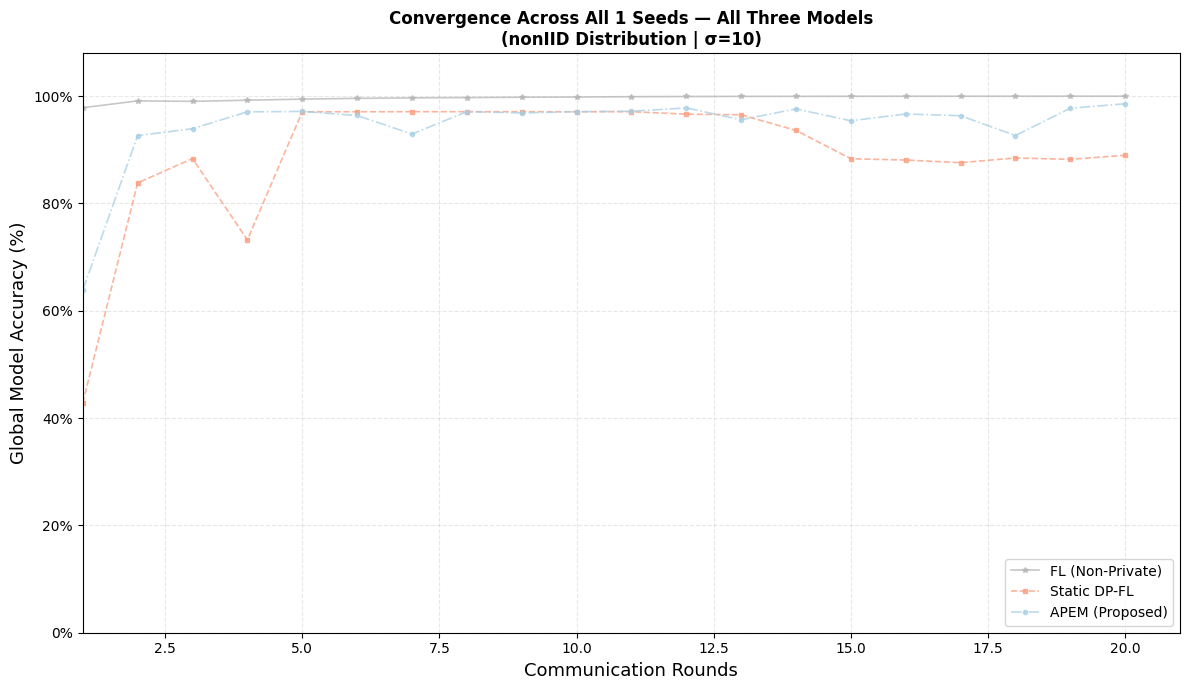

Overlay plot saved to: /content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10/PAI_100000_nonIID_27/convergence_overlay_nonIID.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# COMBINED OVERLAY CONVERGENCE PLOT
# Overlays all seed runs for each model on the same axes.
# FL lines in grey, Static DP-FL in red shades, APEM in blue shades.
# Shows how much variance exists across seeds for each model.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, 7))

# Load per-seed convergence data from saved log files
# We re-extract acc_history from the per-seed results CSVs via the saved models.
# For the overlay we parse the acc histories we collected during the loop.
# NOTE: acc_history per seed was not stored above — we read from CSV final acc only.
# So the overlay uses the accuracy values across rounds from the training logs.
# Since we redirected stdout to txt, we parse round-level accuracy from those logs.

def parse_acc_history_from_log(log_path):
    """Extract per-round global accuracy from a training log txt file."""
    history = []
    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("Global accuracy:"):
                try:
                    val = float(line.split(":")[1].strip())
                    history.append(val)
                except:
                    pass
    return history

fl_colors   = [plt.cm.Greys(0.4 + 0.5 * i / max(len(SEEDS)-1, 1))   for i in range(len(SEEDS))]
dpfl_colors = [plt.cm.Reds(0.35 + 0.5 * i / max(len(SEEDS)-1, 1))   for i in range(len(SEEDS))]
apem_colors = [plt.cm.Blues(0.35 + 0.5 * i / max(len(SEEDS)-1, 1))  for i in range(len(SEEDS))]

for run_idx, seed in enumerate(SEEDS):
    seed_folder = os.path.join(RESULTS_ROOT, f"{DISTRIBUTION}_seed{seed}")

    fl_hist   = parse_acc_history_from_log(os.path.join(seed_folder, "training_log_fl.txt"))
    dpfl_hist = parse_acc_history_from_log(os.path.join(seed_folder, "training_log_dpfl.txt"))
    apem_hist = parse_acc_history_from_log(os.path.join(seed_folder, "training_log_apem.txt"))

    label_fl   = f"FL s{seed}"   if run_idx == 0 else "_nolegend_"
    label_dpfl = f"DP-FL s{seed}" if run_idx == 0 else "_nolegend_"
    label_apem = f"APEM s{seed}" if run_idx == 0 else "_nolegend_"

    ax.plot(range(1, len(fl_hist)+1),   [v*100 for v in fl_hist],
            color=fl_colors[run_idx],   linewidth=1.2, alpha=0.75,
            linestyle="-",  marker="*", markersize=4,
            label="FL (Non-Private)"  if run_idx == 0 else "_nolegend_")
    ax.plot(range(1, len(dpfl_hist)+1), [v*100 for v in dpfl_hist],
            color=dpfl_colors[run_idx], linewidth=1.2, alpha=0.75,
            linestyle="--", marker="s", markersize=3,
            label="Static DP-FL"      if run_idx == 0 else "_nolegend_")
    ax.plot(range(1, len(apem_hist)+1), [v*100 for v in apem_hist],
            color=apem_colors[run_idx], linewidth=1.2, alpha=0.75,
            linestyle="-.", marker="o", markersize=3,
            label="APEM (Proposed)"   if run_idx == 0 else "_nolegend_")

ax.set_xlabel("Communication Rounds", fontsize=13)
ax.set_ylabel("Global Model Accuracy (%)", fontsize=13)
ax.set_title(
    f"Convergence Across All {len(SEEDS)} Seeds — All Three Models\n"
    f"({DISTRIBUTION} Distribution | σ={NOISE_MULTIPLIER})",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10, loc="lower right")
ax.set_ylim(0, 108)
ax.set_xlim(1, NUM_ROUNDS + 1)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
overlay_path = os.path.join(COMBINED_FOLDER, f"convergence_overlay_{DISTRIBUTION}.png")
plt.savefig(overlay_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Overlay plot saved to: {overlay_path}")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# Prints the combined results grouped by model across all seeds.
# Use this to quickly verify results before writing Chapter 4.
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "═"*75)
print(f"  FINAL COMBINED SUMMARY — {len(SEEDS)} SEEDS | {DISTRIBUTION} DISTRIBUTION")
print("═"*75)
print(f"  {'Seed':<8} {'Model':<18} {'Acc':>7} {'F1':>7} {'Avg ε':>9} {'PU Score':>10} {'CosSim':>8}")
print("─"*75)

for _, row in df_combined.iterrows():
    avg_e  = row["avg_epsilon"]
    pu_s   = row["pu_score"]
    avg_e_str = f"{float(avg_e):>9.4f}" if avg_e != "N/A" else f"{'N/A':>9}"
    pu_str    = f"{float(pu_s):>10.6f}" if pu_s  != "N/A" else f"{'N/A':>10}"
    print(f"  {str(row['seed']):<8} {row['model']:<18} {row['accuracy']:>7.4f} "
          f"{row['f1']:>7.4f} {avg_e_str} {pu_str} {row['gradient_cossim']:>8.4f}")

print("═"*75)
print(f"  Combined CSV : {combined_csv_path}")
print(f"  Overlay plot : {overlay_path}")
print("═"*75)



═══════════════════════════════════════════════════════════════════════════
  FINAL COMBINED SUMMARY — 1 SEEDS | nonIID DISTRIBUTION
═══════════════════════════════════════════════════════════════════════════
  Seed     Model                  Acc      F1     Avg ε   PU Score   CosSim
───────────────────────────────────────────────────────────────────────────
  27       FL (Non-Private)    0.9998  0.9999       N/A        N/A  -0.8247
  27       Static DP-FL        0.8887  0.9396    2.2497   0.395032  -0.6448
  27       APEM                0.9857  0.9926   13.1050   0.075215  -0.6423
═══════════════════════════════════════════════════════════════════════════
  Combined CSV : /content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10/PAI_100000_nonIID_27/1_combined_results_nonIID.csv
  Overlay plot : /content/drive/MyDrive/Thesis Dataset/results/Vivs/NOISE_10/PAI_100000_nonIID_27/convergence_overlay_nonIID.png
═══════════════════════════════════════════════════════════════════════════


In [ ]:
# Beep when done
# Source: https://stackoverflow.com/a/54295274
from google.colab import output
output.eval_js('new Audio("https://upload.wikimedia.org/wikipedia/commons/0/05/Beep-09.ogg").play()')